# 1. 引入

## 1.1 什么是 API？

**API 本质：** 不同软件之间进行交流的一套规则。让你不用关心后端的实现方式，只需要遵循接口规范。

---

**理论：** 用户 ⟺ API ⟺ 服务器（后端服务）   

作为用户无需关心后端服务的实现，只需按接口规范发出请求

**比喻：** 顾客 ⟺ 服务员 ⟺ 后厨

顾客无需了解后厨是怎么做饭的，只需通过服务员传达

**示例：** 你的程序 ⟺ 天气API ⟺ 天气服务商后端

---

**常见的 API 类型：** 地图服务、天气服务、大模型服务……

## 1.2 天气 API 调用示例


- **和风天气：** https://dev.qweather.com/ （月 0-5 万次请求免费）
- **Open-Meteo：** https://open-meteo.com/

---

#### 在我的项目中创建项目

<div align="center">
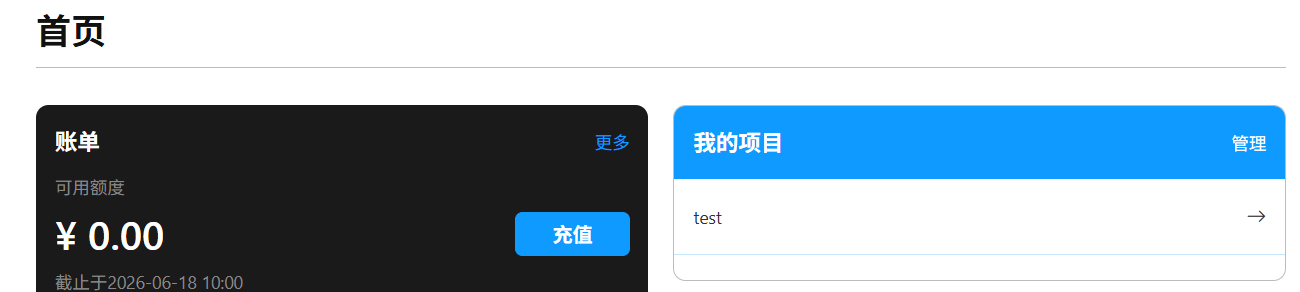
</div>

---

#### 在项目中创建凭据

<div align="center">
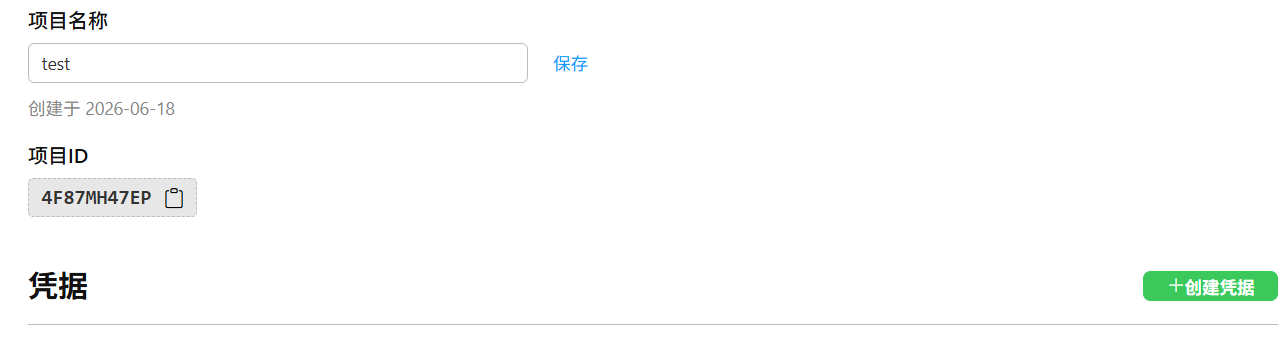
</div>

凭据有两种：

- **JSON Web Token（JWT）**（简单介绍，不必掌握）：用户本地保存私钥并签发签名，服务器后端保存公钥。用户请求服务时发送签名，服务器侧使用公钥验证签名。
- **API KEY**：更常见，在服务请求中通常以 `Authorization: Bearer {your_token}` 形式出现，不记名，谁拿到了都能用。Bearer 在英语中就有不记名证券的意思。

<div align="center">
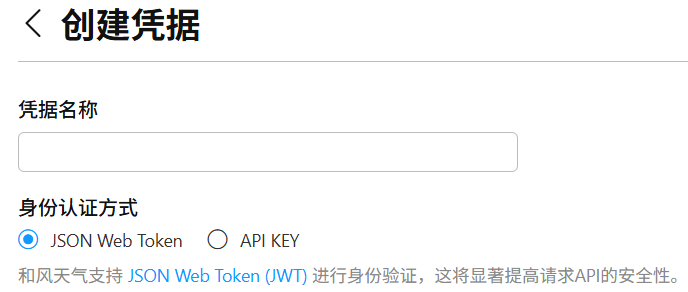
</div>

---

#### 现在创建一个 API，以实时天气预报为例，查看接口调用规范
实时天气预报接口文档: https://dev.qweather.com/docs/api/weather/weather-now/

<div align="center">
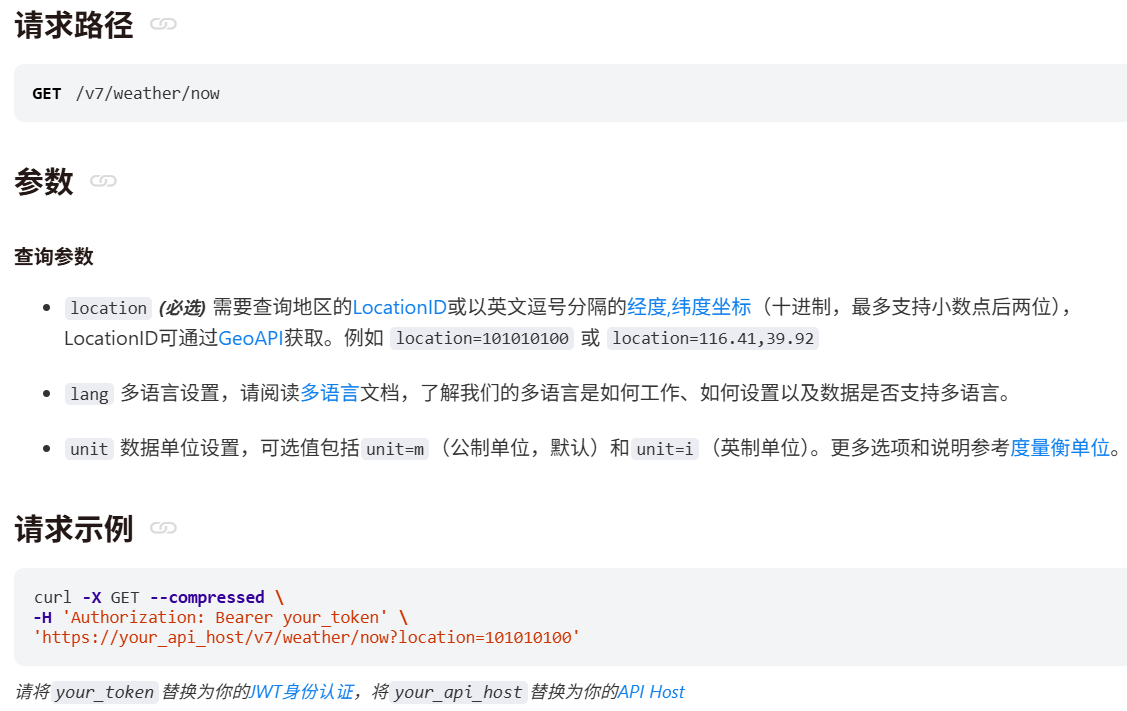
</div>

---

#### API Key 配置
不要把真实 API Key 写进 notebook 或提交到 GitHub。

复制项目根目录的 `.env.example` 为 `.env`，并填入自己的 API Key：

```env
QWEATHER_API_KEY=your_qweather_api_key_here
```

notebook 中会通过下面的方式读取：

```python
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.environ.get("QWEATHER_API_KEY")
```

`.env` 已加入 `.gitignore`，不会被提交至github。


In [1]:
#读取.env中的api_key
from dotenv import load_dotenv
import os
load_dotenv()
api_key = os.environ.get("QWEATHER_API_KEY")

In [5]:
import requests
import json
api_host='mq7aatakea.re.qweatherapi.com'
location='116.41,39.92'
url=f'https://{api_host}/v7/weather/now?location={location}'
headers = {
    'X-QW-Api-Key': api_key
}
response=requests.get(url,headers=headers)
print(response.status_code)  #状态码，反应请求是否成功
print(type(response.text),response.text) #返回响应内容的原始字符串
print()
print(type(response.json()),response.json()) #返回响应内容的 JSON 格式解析，实际是一个python字典

200
<class 'str'> {"code":"200","updateTime":"2026-06-29T08:46+08:00","fxLink":"https://www.qweather.com/weather/dongcheng-101011600.html","now":{"obsTime":"2026-06-29T08:44+08:00","temp":"23","feelsLike":"24","icon":"305","text":"小雨","wind360":"45","windDir":"东北风","windScale":"2","windSpeed":"11","humidity":"86","precip":"0.0","pressure":"1005","vis":"6","cloud":"96","dew":"21"},"refer":{"sources":["QWeather"],"license":["QWeather Developers License"]}}

<class 'dict'> {'code': '200', 'updateTime': '2026-06-29T08:46+08:00', 'fxLink': 'https://www.qweather.com/weather/dongcheng-101011600.html', 'now': {'obsTime': '2026-06-29T08:44+08:00', 'temp': '23', 'feelsLike': '24', 'icon': '305', 'text': '小雨', 'wind360': '45', 'windDir': '东北风', 'windScale': '2', 'windSpeed': '11', 'humidity': '86', 'precip': '0.0', 'pressure': '1005', 'vis': '6', 'cloud': '96', 'dew': '21'}, 'refer': {'sources': ['QWeather'], 'license': ['QWeather Developers License']}}


In [6]:
print(json.dumps(response.json(),ensure_ascii=False,indent=2)) #序列化一个对象到JSON formatted str，可以用来观察响应

{
  "code": "200",
  "updateTime": "2026-06-23T11:04+08:00",
  "fxLink": "https://www.qweather.com/weather/dongcheng-101011600.html",
  "now": {
    "obsTime": "2026-06-23T11:02+08:00",
    "temp": "23",
    "feelsLike": "23",
    "icon": "104",
    "text": "阴",
    "wind360": "45",
    "windDir": "东北风",
    "windScale": "3",
    "windSpeed": "12",
    "humidity": "65",
    "precip": "0.0",
    "pressure": "1004",
    "vis": "15",
    "cloud": "91",
    "dew": "14"
  },
  "refer": {
    "sources": [
      "QWeather"
    ],
    "license": [
      "QWeather Developers License"
    ]
  }
}


In [8]:
#从响应中提取字段并打印
data = response.json()
now = data['now']
print(f"更新时间：{data['updateTime']}")
print(f"天气：{now['text']}")
print(f"温度：{now['temp']}°C（体感 {now['feelsLike']}°C）")
print(f"风向：{now['windDir']} {now['windScale']}级（{now['windSpeed']} km/h）")
print(f"湿度：{now['humidity']}%")
print(f"能见度：{now['vis']} km")

更新时间：2026-06-23T11:04+08:00
天气：阴
温度：23°C（体感 23°C）
风向：东北风 3级（12 km/h）
湿度：65%
能见度：15 km


### 小练习

1. 通过requests库和和风天气服务实现以下功能

用户输入城市名称（如上海）时，能返回该城市大市尺度的未来 3 日天气预报，最终返回如下格式的 DataFrame：

|   | 日期       | 最高温 | 最低温 | 日间天气 | 夜间天气 |
|---|------------|--------|--------|----------|----------|
| 0 | 2026-06-18 | 30     | 24     | 阴       | 小雨     |
| 1 | 2026-06-19 | 28     | 24     | 中雨     | 中雨     |
| 2 | 2026-06-20 | 28     | 23     | 小雨     | 阴       |

#### 答案

In [17]:
import requests
import json
import pandas as pd

city='上海' #用户输入

#先获取城市id
url=f'https://{api_host}/geo/v2/city/lookup?location={city}'
headers = {
    'X-QW-Api-Key': api_key
}
response=requests.get(url,headers=headers)
city_id=response.json()['location'][0]['id']

In [18]:
city_id

'101020100'

In [19]:
#在通过城市id获取3日天气预报
url=f'https://{api_host}/v7/weather/3d?location={city_id}'
headers = {
    'X-QW-Api-Key': api_key
}
response=requests.get(url,headers=headers)
# print(response.status_code)
print(json.dumps(response.json(),indent=2))

{
  "code": "200",
  "updateTime": "2026-06-29T09:03+08:00",
  "fxLink": "https://www.qweather.com/weather/shanghai-101020100.html",
  "daily": [
    {
      "fxDate": "2026-06-29",
      "sunrise": "04:53",
      "sunset": "19:03",
      "moonrise": "18:45",
      "moonset": "03:46",
      "moonPhase": "\u76c8\u51f8\u6708",
      "moonPhaseIcon": "803",
      "tempMax": "28",
      "tempMin": "23",
      "iconDay": "104",
      "textDay": "\u9634",
      "iconNight": "306",
      "textNight": "\u4e2d\u96e8",
      "wind360Day": "135",
      "windDirDay": "\u4e1c\u5357\u98ce",
      "windScaleDay": "1-3",
      "windSpeedDay": "16",
      "wind360Night": "135",
      "windDirNight": "\u4e1c\u5357\u98ce",
      "windScaleNight": "1-3",
      "windSpeedNight": "3",
      "humidity": "95",
      "precip": "1.0",
      "pressure": "1007",
      "vis": "11",
      "cloud": "55",
      "uvIndex": "3"
    },
    {
      "fxDate": "2026-06-30",
      "sunrise": "04:54",
      "sunset": "19:03"

In [19]:
df=pd.DataFrame(response.json()['daily'])[['fxDate','tempMax','tempMin','textDay','textNight']].rename(columns={
    'fxDate': '日期',
    'tempMax': '最高温',
    'tempMin': '最低温',
    'textDay': '日间天气',
    'textNight': '夜间天气'
})
df

,日期,最高温,最低温,日间天气,夜间天气
0,2026-06-23,23,21,中雨,小雨
1,2026-06-24,25,22,小雨,阴
2,2026-06-25,27,22,阴,多云


## 1.3 通过百度千帆平台调用天气API

#### 配置 API 节点
千帆平台:https://console.bce.baidu.com/qianfan/studio/personalSpace/app

1. 先配置 `base_url`
2. 再设置 `params`、`headers`
3. 依次点击发送、解析到输出参数

<div align="center">
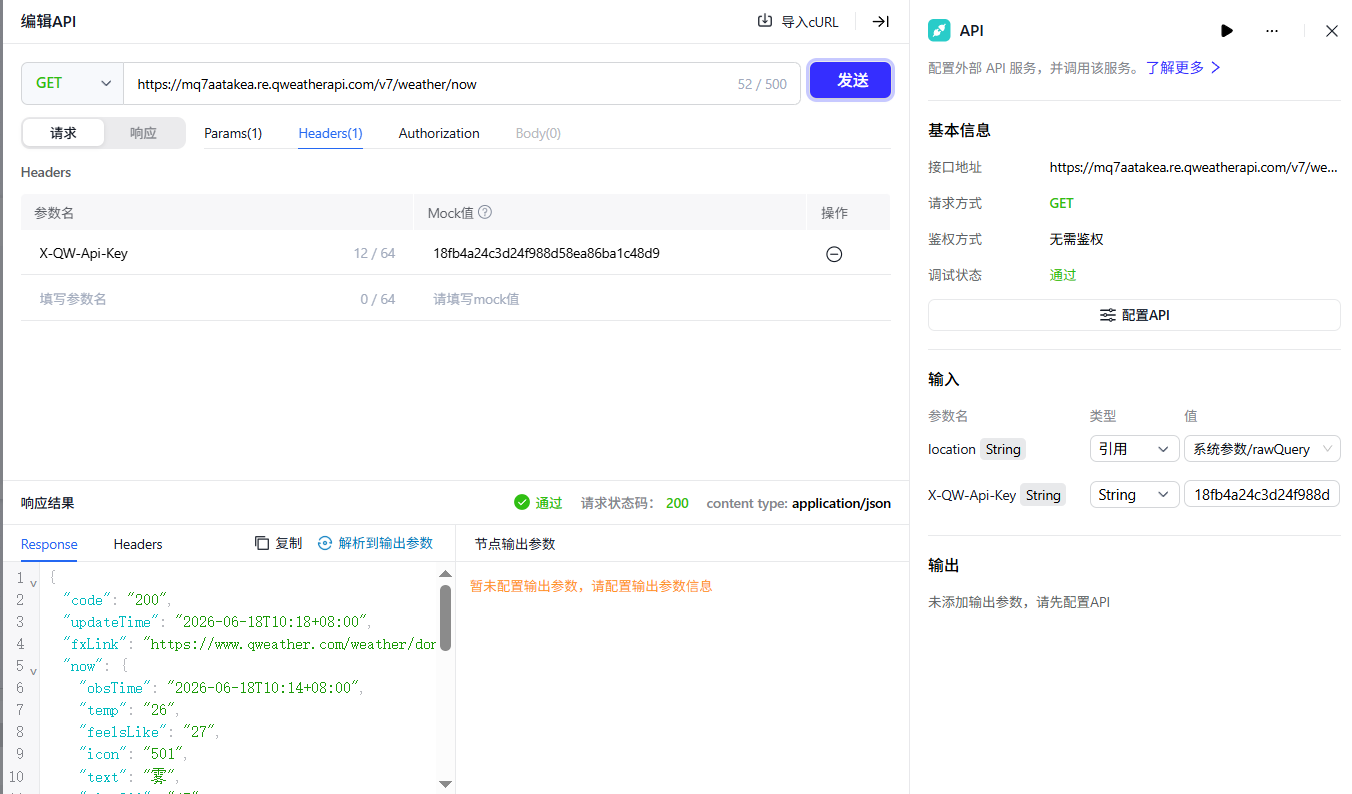
</div>

---

实现用户输入经纬度，智能体输出当地当时的天气

<div align="center">
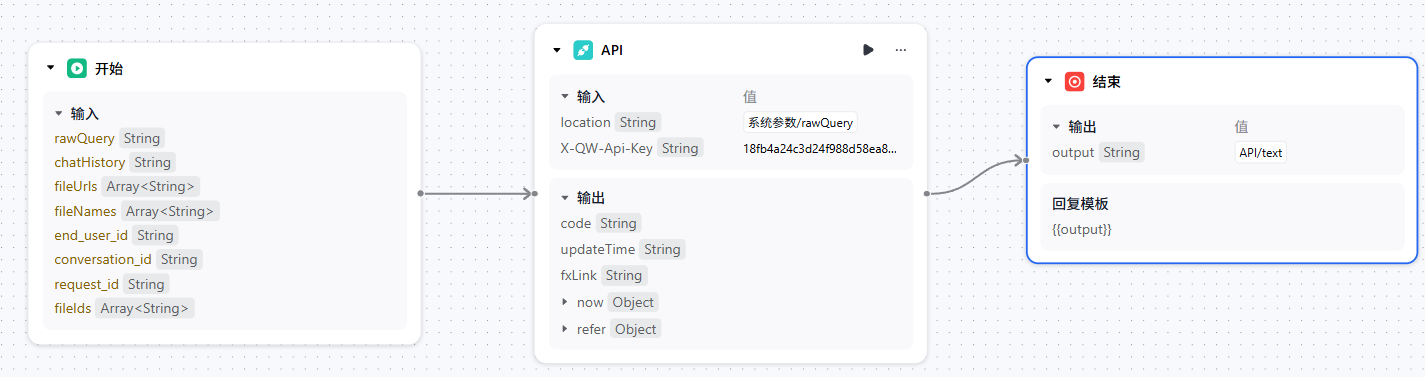
</div>

### 小练习

通过千帆平台实现

用户输入城市名称（如上海）时，能返回该城市大市尺度的未来 3 日天气预报，最终返回和 1 格式类似的表格。

<details>
<summary style="cursor:pointer; font-size:16px; font-weight:bold;">答案（点击展开）</summary>

<div align="center">
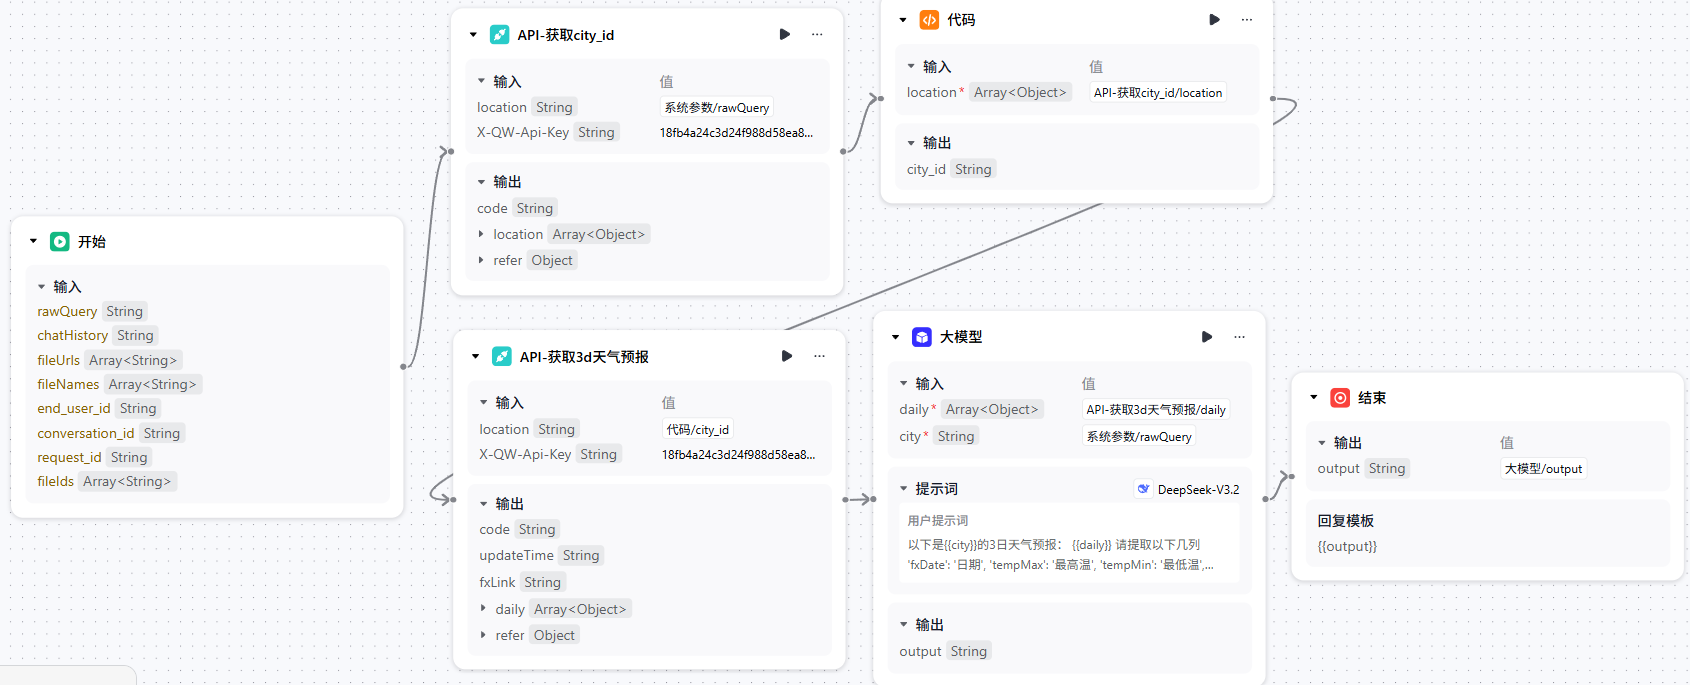
</div>
<div align="center">
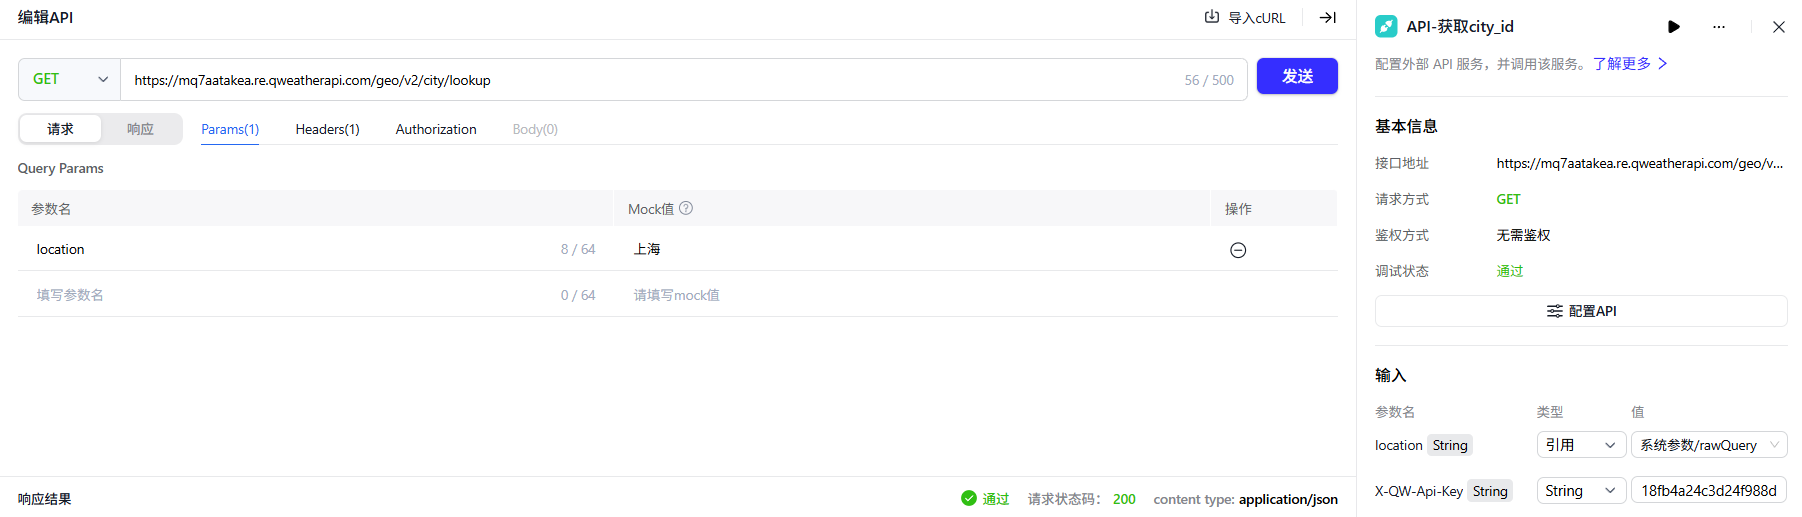
</div>
<div align="center">
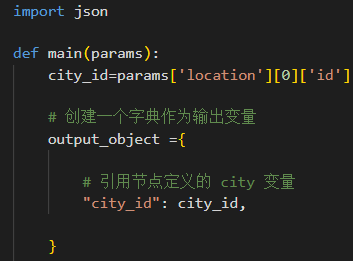
</div>
<div align="center">
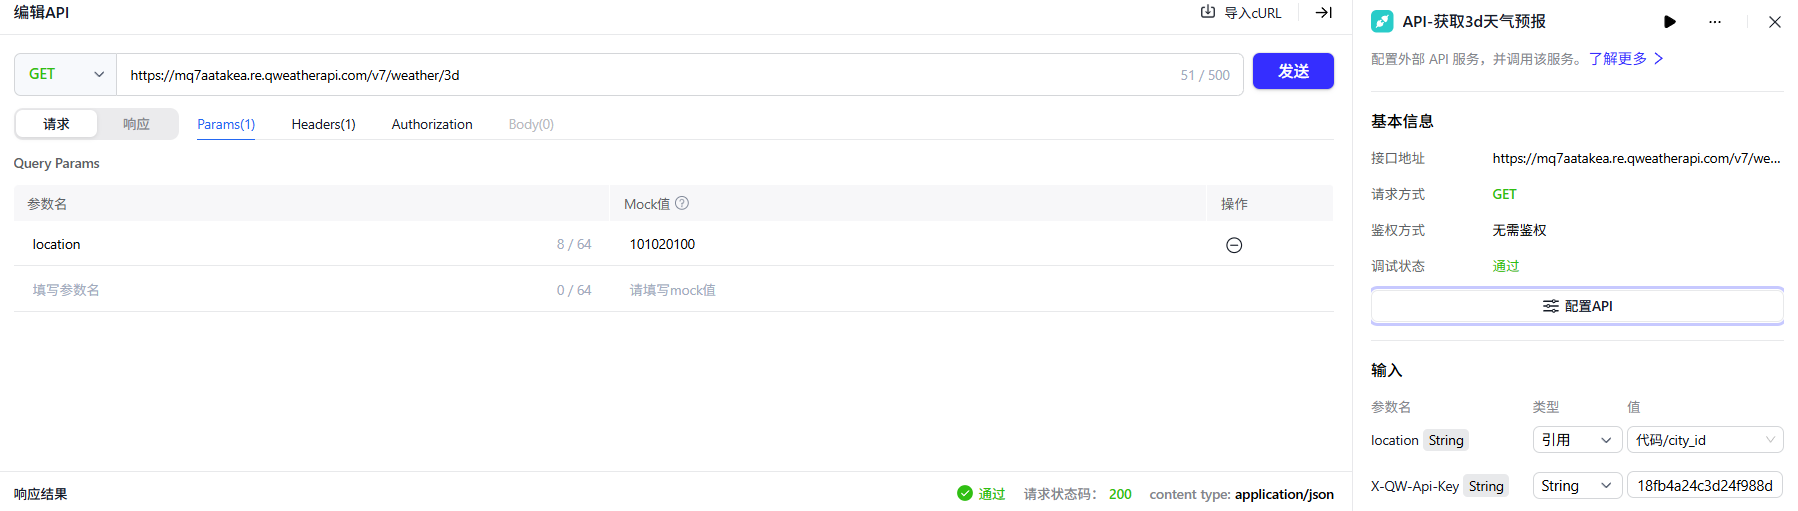
</div>

<h3>大模型模块提示词</h3>
<pre>
以下是{{city}}的3日天气预报：
{{daily}}
请提取以下几列
    'fxDate': '日期',
    'tempMax': '最高温',
    'tempMin': '最低温',
    'textDay': '日间天气',
    'textNight': '夜间天气'
，最后返回格式如下示例：

        日期          最高温  最低温  日间天气  夜间天气
    0   2026-06-18    30      24      阴        小雨
    1   2026-06-19    28      24      中雨      中雨
    2   2026-06-20    28      23      小雨      阴

最终只返回表格，不要返回其他内容
</pre>

</details>

# 2. curl工具

## 2.1 curl工具简介

`curl` 是一个命令行工具，用来发送网络请求和传输数据。

- 通常 API 服务站点都会包含 curl 示例
- Win11 和 Linux 系统通常自带 curl 工具，可以直接在命令行界面使用

---

### 使用示例

**GET 请求（默认）**

```bash
curl https://api.example.com/users
```

**POST 请求**（`-X` 指定请求方法，`-H` 添加请求头，`-d` 指定请求体数据）

```bash
curl -X POST https://api.example.com/users \
  -H "Content-Type: application/json" \
  -d '{"name": "Alice"}'
```

---
以 1.2 的实时天气查询 API 为例

对应的 curl 命令是：

```bash
!curl --compressed "https://mq7aatakea.re.qweatherapi.com/v7/weather/now?location=116.41,39.92" \
    -H "X-QW-Api-Key: {your_key}"
```

`--compressed`：告诉 curl 返回内容是二进制/压缩格式，让 curl 自动解压。

注意：在python中调用curl要用双引号。

In [68]:
!curl --compressed "https://mq7aatakea.re.qweatherapi.com/v7/weather/now?location=116.41,39.92" \
    -H "X-QW-Api-Key: <yourkey>"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100   314  100   314    0     0    841      0 --:--:-- --:--:-- --:--:--   846


{"code":"200","updateTime":"2026-06-18T14:53+08:00","fxLink":"https://www.qweather.com/weather/dongcheng-101011600.html","now":{"obsTime":"2026-06-18T14:50+08:00","temp":"29","feelsLike":"31","icon":"104","text":"闃�","wind360":"45","windDir":"涓滃寳椋�","windScale":"2","windSpeed":"10","humidity":"70","precip":"0.0","pressure":"1001","vis":"4","cloud":"100","dew":"22"},"refer":{"sources":["QWeather"],"license":["QWeather Developers License"]}}


## 2.1 小练习

对任意城市，使用curl调用和风天气预报的每日天气预报接口

<details>
<summary style="cursor:pointer; font-size:16px; font-weight:bold;">答案（点击展开）</summary>
!curl --compressed "https://mq7aatakea.re.qweatherapi.com/v7/weather/3d?location=101010100" -H "X-QW-Api-Key: you_key" 
</pre>

</details>

# 3. json库

`json` 是 Python 内置的标准库，用于在 **Python 对象**(主要是字典) 和 **JSON 字符串** 之间进行转换。

### 核心概念：序列化 与 反序列化

| 术语 | 含义 | 方向 |
|---|---|---|
| 序列化（serialize） | 把 Python 对象转换成 JSON 字符串 | Python → JSON |
| 反序列化（deserialize） | 把 JSON 字符串转换成 Python 对象 | JSON → Python |
> 注意：JSON字符串本质也是字符串

### 3.1 序列化：`json.dumps()`

把 Python 的字典、列表等对象转换成 JSON 格式的字符串。
尝试运行以下代码：

In [29]:
import json

data = {"name": "Alice", "age": 20, "tags": ["VIP", "新用户"]}

json_str = json.dumps(data)
print(json_str)
print(type(json_str))  # 

{"name": "Alice", "age": 20, "tags": ["VIP", "\u65b0\u7528\u6237"]}
<class 'str'>


默认情况下中文会被转成 Unicode 转义（`\u65b0\u7528\u6237`），不是乱码，只是显示形式。如果想直接看到中文，加上 `ensure_ascii=False`，运行以下代码

In [30]:
json_str = json.dumps(data, ensure_ascii=False)
print(json_str)

{"name": "Alice", "age": 20, "tags": ["VIP", "新用户"]}


如果我们想让输出更美观易读，可以加上indent缩进

In [32]:
json_str = json.dumps(data, indent=2,ensure_ascii=False)
print(json_str)

{
  "name": "Alice",
  "age": 20,
  "tags": [
    "VIP",
    "新用户"
  ]
}


#### 练习

把下面这个字典转换成 JSON 字符串，并确保中文不被转成 \uXXXX 编码。

In [28]:
info = {"name": "sun", "tools": ["Python", "Jupyter"]}

#### 答案

In [29]:
json.dumps(info,ensure_ascii=False)

'{"name": "sun", "tools": ["Python", "Jupyter"]}'

### 3.2. 反序列化：`json.loads()`

把 JSON 格式的字符串转换成 Python 对象（字典/列表）。

In [33]:
import json

json_str = '{"name": "Alice", "age": 20}'

data = json.loads(json_str)
print(data)
print(type(data))  # <class 'dict'>
print(data["name"])  # Alice

{'name': 'Alice', 'age': 20}
<class 'dict'>
Alice


#### 练习

给定一个 JSON 格式的字符串，把它转换成 Python 字典，并打印出 name 字段的值。

In [31]:
json_str = '{"name": "sun", "age": 28, "city": "Beijing"}'

#### 答案

In [33]:
json.loads(json_str)['name']

'sun'

### 3.3 处理文件：`json.dump()` 与 `json.load()`

如果数据来源/去向是**文件**而不是字符串，用不带 `s` 的版本，可以直接读写文件对象：

In [35]:
import json,os

data = {"name": "Alice", "age": 20}

# 将python对象序列化后写入文件
with open("data.json", "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

# 从文件读取json字符串并转python对象
with open("data.json", "r", encoding="utf-8") as f:
    loaded_data = json.load(f)
print(loaded_data)

# try:
#     os.remove('data.json') #删除文件
# except:
#     pass

{'name': 'Alice', 'age': 20}


#### 练习

把以下字典写入到一个名为 config.json 的文件中，要求格式化输出（缩进2个空格）

In [35]:
config = {"api_key_env": "QIANFAN_API_KEY", "model": "deepseek-v4-flash", "temperature": 0.7}

#### 答案

In [36]:
with open('config.json','w',encoding='utf-8') as f:
    json.dump(config,f,indent=2)

### 3.4 常见报错：`JSONDecodeError`

当字符串不是合法的 JSON 格式时，`json.loads()` 会报错.

常见问题：单引号代替双引号、多了个逗号、字符串没闭合等等

In [40]:
import json
#正确示例
try:
    json.loads('{"name":"john"}')
except json.JSONDecodeError as e:
    print("解析失败：", e)

In [41]:
#常见错误示例：内部单引号
try:
    json.loads("{'name':'john'}")
except json.JSONDecodeError as e:
    print("解析失败：", e)

解析失败： Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
